Approach:
preprocess → grayscale → Otsu threshold → findContours → approxPolyDP → sort corners


found 6363 images



processing: 100%|██████████| 6363/6363 [1:11:30<00:00,  1.48it/s]


                                                   image  status  matched  accuracy   d_BR    d_BL    d_TL   d_TR
  A0044MGO_Flash0_A0044MGOfullhd_1632980533838_2.0.7.png no_quad        0       0.0    NaN     NaN     NaN    NaN
  A0044MGO_Flash0_A0044MGOfullhd_1632981769373_2.0.7.png no_quad        0       0.0    NaN     NaN     NaN    NaN
  A0044MGO_Flash0_A0044MGOfullhd_1632988548141_2.0.7.png      ok        4     100.0   3.16    8.06    2.83   2.83
  A0044MGO_Flash0_A0044MGOfullhd_1633001123311_2.0.7.png      ok        0       0.0  79.65   81.34   82.88  79.63
  A0044MGO_Flash0_A0044MGOfullhd_1633066408783_2.0.7.png      ok        0       0.0  79.65   84.22   87.11  82.10
  A0044MGO_Flash0_A0044MGOfullhd_1633072326791_2.0.7.png      ok        4     100.0   2.24    2.00    1.00   2.24
  A0044MGO_Flash0_A0044MGOfullhd_1633082942471_2.0.7.png no_quad        0       0.0    NaN     NaN     NaN    NaN
  A0044MGP_Flash0_A0044MGPfullhd_1632983258465_2.0.7.png      ok        4     100.0   3.

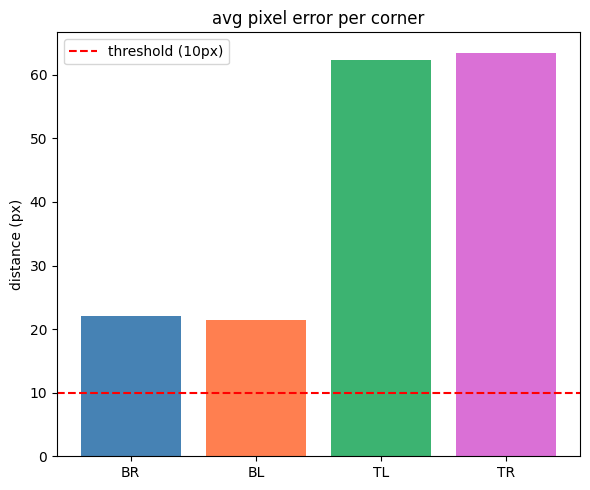

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_FOLDER  = "/content/drive/MyDrive/tag_boundary_detection_training_data/flash_images"
CORNERS_CSV   = "/content/drive/MyDrive/tag_boundary_detection_training_data/corners.csv"
OUTPUT_FOLDER = "output"
MIN_AREA      = 25000
MAX_AREA      = 100000
DIST_THRESH   = 10


def preprocess(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    result = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    return result


def compute_accuracy(calculated_corners, gt_points):
    distances = []
    matched = 0
    for (px, py), (gx, gy) in zip(calculated_corners, gt_points):
        d = np.linalg.norm(np.array([px, py]) - np.array([gx, gy]))
        distances.append(round(float(d), 2))
        if d <= DIST_THRESH:
            matched += 1
    accuracy = (matched / 4) * 100
    return distances, matched, accuracy


def process_image(image_path, gtcsv):
    filename = os.path.basename(image_path)
    image = cv2.imread(str(image_path))

    result_row = {
        "image": filename,
        "status": "ok",
        "matched": 0,
        "accuracy": 0.0,
        "d_BR": None, "d_BL": None, "d_TL": None, "d_TR": None,
    }

    if image is None:
        print(f"cant read {filename}, skipping")
        result_row["status"] = "unreadable"
        return result_row, None

    image = preprocess(image)
    vis = image.copy()

    poly = []
    valid_indices = []

    src = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, src = cv2.threshold(src, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, hierarchy = cv2.findContours(src, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

    for cnt_idx, cnt in enumerate(contours):
        epsilon = 0.02 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        if len(approx) == 4:
            area = cv2.contourArea(approx)
            if MIN_AREA < area < MAX_AREA and cv2.isContourConvex(approx):
                poly.append(approx)
                valid_indices.append(cnt_idx)

    for idx in range(len(poly)):
        cv2.drawContours(vis, poly, idx, (0, 255, 0), 2)

    if len(poly) == 0:
        result_row["status"] = "no_quad"
        cv2.imwrite(os.path.join(OUTPUT_FOLDER, filename), vis)
        return result_row, vis

    first_quad = poly[0]
    corners = first_quad.reshape(4, 2)

    # show raw corners before sorting
    for (x, y) in corners:
        cv2.circle(vis, (int(x), int(y)), 5, (255, 255, 0), -1)

    sorted_by_y = sorted(corners, key=lambda c: c[1])
    top_left, top_right = sorted(sorted_by_y[:2], key=lambda c: c[0])
    bottom_left, bottom_right = sorted(sorted_by_y[2:], key=lambda c: c[0])

    calculated_corners = [bottom_right, bottom_left, top_left, top_right]
    corner_labels = ["BR", "BL", "TL", "TR"]

    for i, (x, y) in enumerate(calculated_corners):
        cv2.circle(vis, (int(x), int(y)), 8, (0, 0, 255), -1)
        cv2.putText(vis, str(i), (int(x) + 5, int(y) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    gt_row = gtcsv.loc[gtcsv["filename"] == filename]

    if len(gt_row) == 0:
        result_row["status"] = "no_gt"
        cv2.imwrite(os.path.join(OUTPUT_FOLDER, filename), vis)
        return result_row, vis

    coord_string = gt_row.iloc[0].values[1]
    coords = list(map(float, str(coord_string).split()))

    if len(coords) != 8:
        result_row["status"] = "gt_format_error"
        cv2.imwrite(os.path.join(OUTPUT_FOLDER, filename), vis)
        return result_row, vis

    gt_points = [(int(coords[i]), int(coords[i + 1])) for i in range(0, 8, 2)]

    # draw gt
    for i in range(4):
        cv2.line(vis, gt_points[i], gt_points[(i + 1) % 4], (255, 0, 255), 2)
    for (x, y) in gt_points:
        cv2.circle(vis, (x, y), 6, (0, 255, 255), -1)

    distances, matched, accuracy = compute_accuracy(calculated_corners, gt_points)

    # recolor predicted corners now that we know distances
    for i, (x, y) in enumerate(calculated_corners):
        color = (0, 255, 0) if distances[i] <= DIST_THRESH else (0, 0, 255)
        cv2.circle(vis, (int(x), int(y)), 8, color, -1)
        cv2.putText(vis, f"{corner_labels[i]}({distances[i]:.1f}px)",
                    (int(x) + 5, int(y) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)

    cv2.imwrite(os.path.join(OUTPUT_FOLDER, filename), vis)

    result_row.update({
        "status": "ok",
        "matched": matched,
        "accuracy": round(accuracy, 2),
        "d_BR": distances[0],
        "d_BL": distances[1],
        "d_TL": distances[2],
        "d_TR": distances[3],
    })

    return result_row, vis


def plot_results(df):
    ok = df[df["status"] == "ok"]
    if ok.empty:
        print("nothing to plot")
        return

    avg_dists = [ok[c].dropna().mean() for c in ["d_BR", "d_BL", "d_TL", "d_TR"]]

    plt.figure(figsize=(6, 5))
    plt.bar(["BR", "BL", "TL", "TR"], avg_dists,
            color=["steelblue", "coral", "mediumseagreen", "orchid"])
    plt.axhline(DIST_THRESH, color="red", linestyle="--", label=f"threshold ({DIST_THRESH}px)")
    plt.title("avg pixel error per corner")
    plt.ylabel("distance (px)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "accuracy_plot.png"), dpi=150)
    plt.show()


def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    gtcsv = pd.read_csv(CORNERS_CSV)
    gtcsv.columns = gtcsv.columns.str.strip()

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"}
    images = sorted([p for p in Path(IMAGE_FOLDER).iterdir() if p.suffix.lower() in exts])

    if not images:
        print(f"no images found in {IMAGE_FOLDER}")
        return

    print(f"found {len(images)} images\n")

    results = []
    for img_path in tqdm(images, desc="processing"):
        row, _ = process_image(img_path, gtcsv)
        results.append(row)

    df = pd.DataFrame(results)
    ok = df[df["status"] == "ok"]

    print(df[["image", "status", "matched", "accuracy", "d_BR", "d_BL", "d_TL", "d_TR"]].to_string(index=False))

    if not ok.empty:
        print(f"\ntotal: {len(df)}  |  detected: {len(ok)}  |  failed: {len(df) - len(ok)}")
        print(f"mean accuracy: {ok['accuracy'].mean():.2f}%")
        print(f"fully correct: {(ok['accuracy'] == 100).sum()} / {len(ok)}")
        for c in ["BR", "BL", "TL", "TR"]:
            print(f"  avg error {c}: {ok[f'd_{c}'].mean():.2f} px")

    df.to_csv(os.path.join(OUTPUT_FOLDER, "accuracy_report.csv"), index=False)
    plot_results(df)


if __name__ == "__main__":
    main()

In [ ]:
process_image("/content/drive/MyDrive/tag_boundary_detection_training_data/flash_images/A0044MGO_Flash0_A0044MGOfullhd_1632980533838_2.0.7.png","/content/drive/MyDrive/tag_boundary_detection_training_data/corners.csv")

({'image': 'A0044MGO_Flash0_A0044MGOfullhd_1632980533838_2.0.7.png',
  'status': 'no_quad',
  'matched': 0,
  'accuracy': 0.0,
  'd_BR': None,
  'd_BL': None,
  'd_TL': None,
  'd_TR': None},
 array([[[159, 168, 172],
         [159, 168, 172],
         [168, 177, 181],
         ...,
         [150, 158, 165],
         [153, 161, 168],
         [153, 161, 168]],
 
        [[159, 168, 172],
         [164, 172, 177],
         [164, 172, 177],
         ...,
         [157, 165, 172],
         [153, 161, 168],
         [153, 161, 168]],
 
        [[159, 168, 172],
         [155, 164, 168],
         [159, 168, 172],
         ...,
         [162, 170, 176],
         [157, 165, 172],
         [157, 165, 172]],
 
        ...,
 
        [[160, 175, 183],
         [155, 171, 179],
         [160, 175, 183],
         ...,
         [154, 174, 180],
         [154, 174, 180],
         [154, 174, 180]],
 
        [[155, 171, 179],
         [160, 175, 183],
         [160, 175, 183],
         ...,
         

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_FOLDER    = "flashnew/flashnew"
CORNERS_CSV     = "corners.csv"
OUTPUT_FOLDER   = "output"
DISTANCE_THRESH = 10
SAVE_IMAGES     = True
MIN_AREA        = 25000
MAX_AREA        = 100000


def preprocess(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)


def detect_quad_corners(img):
    h, w = img.shape[:2]
    src = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, src = cv2.threshold(src, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(src, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

    best_quad = None
    max_area = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (MIN_AREA < area < MAX_AREA):
            continue

        epsilon = 0.02 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)

        if len(approx) != 4 or not cv2.isContourConvex(approx):
            continue

        # skip contours that touch the image boundary
        pts = approx.reshape(4, 2)
        margin_x = w * 0.05
        margin_y = h * 0.05
        on_border = any(
            x < margin_x or x > w - margin_x or
            y < margin_y or y > h - margin_y
            for x, y in pts
        )
        if on_border:
            continue

        if area > max_area:
            best_quad = approx
            max_area = area

    if best_quad is None:
        return None, None

    corners = best_quad.reshape(4, 2)
    sorted_y = sorted(corners, key=lambda c: c[1])
    top_left, top_right = sorted(sorted_y[:2], key=lambda c: c[0])
    bot_left, bot_right = sorted(sorted_y[2:], key=lambda c: c[0])

    return [bot_right, bot_left, top_left, top_right], best_quad


def parse_gt_row(gt_row):
    if len(gt_row) == 0:
        return None

    coord_string = gt_row.iloc[0].values[1]
    coords = list(map(float, str(coord_string).split()))

    if len(coords) != 8:
        return None

    return [(int(coords[i]), int(coords[i + 1])) for i in range(0, 8, 2)]


def compute_accuracy(predicted, gt_points):
    if not gt_points or not predicted:
        return [], 0, 0.0

    distances = []
    matched = 0

    for (px, py), (gx, gy) in zip(predicted, gt_points):
        d = np.linalg.norm(np.array([px, py]) - np.array([gx, gy]))
        distances.append(round(d, 2))
        if d <= DISTANCE_THRESH:
            matched += 1

    accuracy = (matched / len(gt_points)) * 100
    return distances, matched, accuracy


def annotate(img, best_quad, predicted, gt_points, distances):
    vis = img.copy()
    corner_labels = ["BR", "BL", "TL", "TR"]

    if best_quad is not None:
        cv2.drawContours(vis, [best_quad], 0, (0, 255, 0), 2)

    if gt_points:
        for i in range(4):
            cv2.line(vis, gt_points[i], gt_points[(i + 1) % 4], (255, 0, 255), 2)
        for (x, y) in gt_points:
            cv2.circle(vis, (x, y), 6, (0, 255, 255), -1)

    for i, (x, y) in enumerate(predicted):
        dist = distances[i] if distances else float("inf")
        color = (0, 255, 0) if dist <= DISTANCE_THRESH else (0, 0, 255)
        cv2.circle(vis, (int(x), int(y)), 8, color, -1)
        label = f"{corner_labels[i]} ({dist:.1f}px)" if distances else corner_labels[i]
        cv2.putText(vis, label, (int(x) + 6, int(y) - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return vis


def process_image(img_path, gtcsv):
    filename = os.path.basename(img_path)
    img = cv2.imread(str(img_path))

    result_row = {
        "image": filename, "status": "ok", "matched": 0, "accuracy": 0.0,
        "d_BR": None, "d_BL": None, "d_TL": None, "d_TR": None,
    }

    if img is None:
        result_row["status"] = "unreadable"
        return result_row

    img = preprocess(img)
    predicted, best_quad = detect_quad_corners(img)

    if predicted is None:
        result_row["status"] = "no_quad"
        if SAVE_IMAGES:
            cv2.imwrite(os.path.join(OUTPUT_FOLDER, filename), img)
        return result_row

    gt_row = gtcsv.loc[gtcsv["filename"] == filename]
    gt_points = parse_gt_row(gt_row)

    distances, matched, accuracy = compute_accuracy(predicted, gt_points or [])
    vis = annotate(img, best_quad, predicted, gt_points or [], distances)

    if SAVE_IMAGES:
        cv2.imwrite(os.path.join(OUTPUT_FOLDER, filename), vis)

    result_row.update({
        "status": "ok",
        "matched": matched,
        "gt_total": len(gt_points) if gt_points else 0,
        "accuracy": round(accuracy, 2),
        "d_BR": distances[0] if len(distances) > 0 else None,
        "d_BL": distances[1] if len(distances) > 1 else None,
        "d_TL": distances[2] if len(distances) > 2 else None,
        "d_TR": distances[3] if len(distances) > 3 else None,
    })

    return result_row


def plot_results(df):
    ok = df[df["status"] == "ok"]
    if ok.empty:
        print("nothing to plot")
        return

    avg_dists = [ok[c].dropna().mean() for c in ["d_BR", "d_BL", "d_TL", "d_TR"]]

    plt.figure(figsize=(6, 5))
    plt.bar(["BR", "BL", "TL", "TR"], avg_dists,
            color=["steelblue", "coral", "mediumseagreen", "orchid"])
    plt.axhline(DISTANCE_THRESH, color="red", linestyle="--",
                label=f"threshold ({DISTANCE_THRESH}px)")
    plt.title("avg pixel error per corner")
    plt.ylabel("distance (px)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "accuracy_plot.png"), dpi=150)
    plt.show()


def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    gtcsv = pd.read_csv(CORNERS_CSV)
    gtcsv.columns = gtcsv.columns.str.strip()

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"}
    images = sorted([p for p in Path(IMAGE_FOLDER).iterdir() if p.suffix.lower() in exts])

    if not images:
        print(f"no images found in {IMAGE_FOLDER}")
        return

    print(f"found {len(images)} images\n")

    results = []
    for img_path in tqdm(images, desc="processing"):
        results.append(process_image(img_path, gtcsv))

    df = pd.DataFrame(results)
    ok = df[df["status"] == "ok"]

    print(df[["image", "status", "matched", "accuracy", "d_BR", "d_BL", "d_TL", "d_TR"]].to_string(index=False))

    if not ok.empty:
        print(f"\ntotal: {len(df)}  |  detected: {len(ok)}  |  failed: {len(df) - len(ok)}")
        print(f"mean accuracy: {ok['accuracy'].mean():.2f}%")
        print(f"fully correct: {(ok['accuracy'] == 100).sum()} / {len(ok)}")
        for c in ["BR", "BL", "TL", "TR"]:
            print(f"  avg error {c}: {ok[f'd_{c}'].mean():.2f} px")

    df.to_csv(os.path.join(OUTPUT_FOLDER, "accuracy_report.csv"), index=False)
    plot_results(df)


if __name__ == "__main__":
    main()